<a href="https://colab.research.google.com/github/Elamathi995/QA_QC/blob/main/QA_QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import itertools
import numpy as np

# Factors
force = [5, 10]  # kN
moisture = [2, 5]  # %
# Design
design = list(itertools.product(force, moisture))
df = pd.DataFrame(design, columns=["Force", "Moisture"])
# Simulate defect rate (%)
np.random.seed(1)
df["DefectRate"] = (
   10 - 0.8 * df["Force"] +
   1.5 * df["Moisture"] +
   0.5 * df["Force"] * df["Moisture"] +
   np.random.normal(0, 1, len(df))
)
print(df)


   Force  Moisture  DefectRate
0      5         2   15.624345
1      5         5   25.388244
2     10         2   14.471828
3     10         5   33.427031


In [ ]:
import statsmodels.formula.api as smf
model = smf.ols("DefectRate ~ Force + Moisture + Force:Moisture", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             DefectRate   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 04 May 2026   Prob (F-statistic):                nan
Time:                        13:48:08   Log-Likelihood:                 123.74
No. Observations:                   4   AIC:                            -239.5
Df Residuals:                       0   BIC:                            -241.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         16.3951        inf        

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [ ]:
import numpy as np
# The pyDOE2 library is incompatible with Python 3.12 due to its reliance on the 'imp' module, which has been removed.
# You might need to find an alternative library for Design of Experiments (DOE) or use an environment with an older Python version.
# For now, I'm commenting out the problematic code.
# !pip install pyDOE2
# from pyDOE2 import ccdesign
# design = ccdesign(2)
# df = pd.DataFrame(design, columns=["Force", "Moisture"])
# df["DefectRate"] = (
#    8 - 1.2*df["Force"] + 1.8*df["Moisture"]
#    + 0.5*df["Force"]*df["Moisture"]
#    + df["Force"]**2 + df["Moisture"]**2
#    + np.random.normal(0, 0.5, len(df))
# )
# print(df)

In [ ]:
speed = [100, 200]
temp = [25, 40]
operator = [1, 2]
design = list(itertools.product(speed, temp, operator))
df = pd.DataFrame(design, columns=["Speed", "Temp", "Operator"])
df["Defects"] = (
   20 - 0.05*df["Speed"] +
   0.8*df["Temp"] -
   2*df["Operator"] +
   0.01*df["Speed"]*df["Temp"] +
   np.random.normal(0, 2, len(df))
)
print(df)


   Speed  Temp  Operator     Defects
0    100    25         1   59.730815
1    100    25         2   51.396923
2    100    40         1   88.489624
3    100    40         2   81.477586
4    200    25         1   78.638078
5    200    25         2   75.501259
6    200    40         1  122.924216
7    200    40         2  113.879719


In [ ]:
# Define specification limit
USL = 10  # upper spec limit
df["WithinSpec"] = df["Defects"] < USL
print(df[["Speed", "Temp", "Operator", "Defects", "WithinSpec"]])

   Speed  Temp  Operator     Defects  WithinSpec
0    100    25         1   59.730815       False
1    100    25         2   51.396923       False
2    100    40         1   88.489624       False
3    100    40         2   81.477586       False
4    200    25         1   78.638078       False
5    200    25         2   75.501259       False
6    200    40         1  122.924216       False
7    200    40         2  113.879719       False


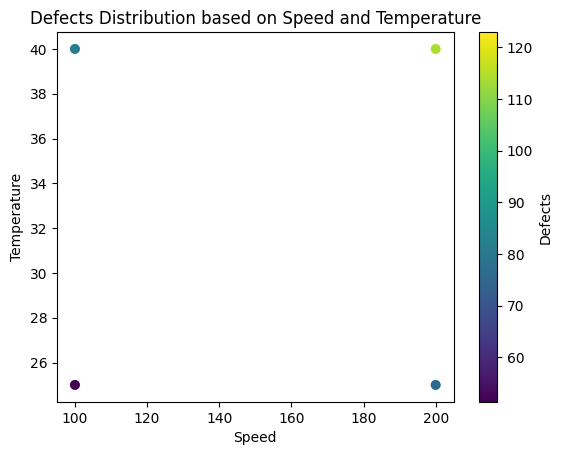

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Speed"], df["Temp"], c=df["Defects"])
plt.colorbar(label="Defects")
plt.xlabel("Speed")
plt.ylabel("Temperature")
plt.title("Defects Distribution based on Speed and Temperature")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)
# create sample data
operators = ['A', 'B', 'C']
batches = [f'B{i}' for i in range(1, 11)]
data = []
for b in batches:
    for op in operators:
        diameter = np.random.normal(10.00, 0.05, 5)   # mean 10mm, SD 0.05
        weight = np.random.normal(5.0, 0.1, 5)
        for d, w in zip(diameter, weight):
            data.append([b, op, d, w])

df = pd.DataFrame(data, columns=['Batch', 'Operator', 'Diameter', 'Weight'])
df.head()

df.to_csv('QAQC_data.csv', index=False)


         Diameter      Weight
count  150.000000  150.000000
mean     9.997992    5.002905
std      0.050723    0.095511
min      9.837937    4.797486
25%      9.961151    4.936049
50%      9.998442    5.008940
75%     10.032109    5.057688
max     10.123162    5.385273


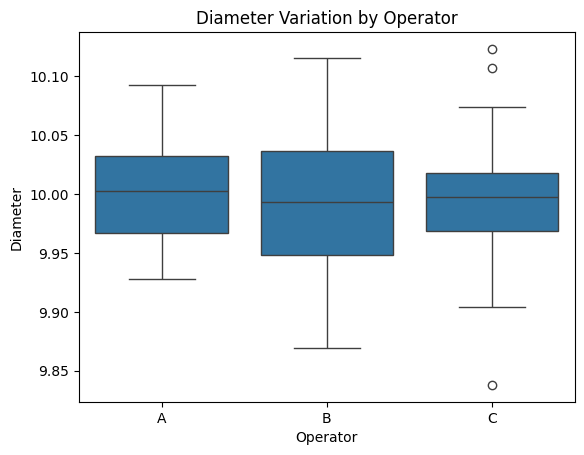

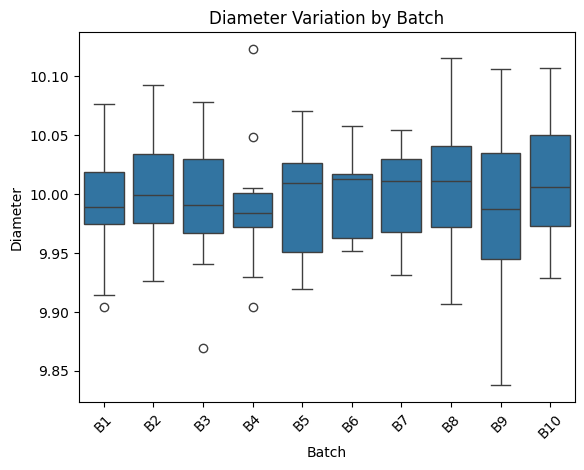

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats
print(df.describe())

# Boxplots for process variation
sns.boxplot(x='Operator', y='Diameter', data=df)
plt.title('Diameter Variation by Operator')
plt.show()

sns.boxplot(x='Batch', y='Diameter', data=df)
plt.xticks(rotation=45)
plt.title('Diameter Variation by Batch')
plt.show()


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Diameter ~ C(Operator)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

               sum_sq     df         F    PR(>F)
C(Operator)  0.002291    2.0  0.441874  0.643681
Residual     0.381061  147.0       NaN       NaN


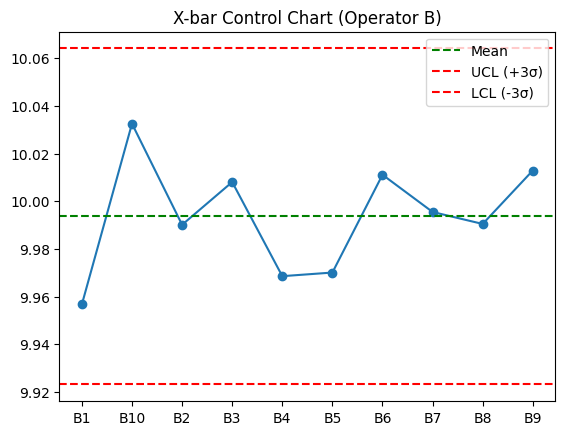

In [ ]:
grouped = df[df['Operator']=='B'].groupby('Batch')['Diameter'].mean()

mean = grouped.mean()
std = grouped.std()
UCL = mean + 3*std
LCL = mean - 3*std

plt.plot(grouped.index, grouped.values, marker='o')
plt.axhline(mean, color='green', linestyle='--', label='Mean')
plt.axhline(UCL, color='red', linestyle='--', label='UCL (+3σ)')
plt.axhline(LCL, color='red', linestyle='--', label='LCL (-3σ)')
plt.title('X-bar Control Chart (Operator B)')
plt.legend()
plt.show()

In [ ]:
USL = 10.10
LSL = 9.90
sigma = df['Diameter'].std()
Cp = (USL - LSL) / (6*sigma)
Cpk = min((USL - df['Diameter'].mean()) / (3*sigma),
          (df['Diameter'].mean() - LSL) / (3*sigma))
print(f"Cp = {Cp:.2f},  Cpk = {Cpk:.2f}")


Cp = 0.66,  Cpk = 0.64


In [ ]:
import pandas as pd, numpy as np
np.random.seed(7)

operators = ['A','B','C']
parts = [f'P{i}' for i in range(1,11)]

data=[]
for op in operators:
    for p in parts:
        readings = np.random.normal(50, 0.2, 2)   # two readings per part/operator
        for r in readings:
            data.append([op,p,r])
grr_df = pd.DataFrame(data, columns=['Operator','Part','Measurement'])
grr_df.head()


,Operator,Part,Measurement
0,A,P1,50.338105
1,A,P1,49.906813
2,A,P2,50.006564
3,A,P2,50.081503
4,A,P3,49.842215


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Measurement ~ C(Operator) + C(Part) + C(Operator):C(Part)', data=grr_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                       sum_sq    df         F    PR(>F)
C(Operator)          0.017029   2.0  0.191159  0.826999
C(Part)              0.572627   9.0  1.428433  0.220371
C(Operator):C(Part)  0.750026  18.0  0.935480  0.548036
Residual             1.336259  30.0       NaN       NaN


In [ ]:
temp = np.random.normal(200, 5, 50)
speed = np.random.normal(100, 10, 50)
weight = 5 + 0.02*temp - 0.015*speed + np.random.normal(0,0.1,50)
df2 = pd.DataFrame({'Temp':temp,'Speed':speed,'Weight':weight})
df2.head()


,Temp,Speed,Weight
0,198.155908,97.120161,7.413383
1,190.468151,102.998084,7.305571
2,199.501947,110.559483,7.517652
3,208.497686,105.658825,7.435344
4,198.082884,87.664761,7.694320


In [ ]:
import statsmodels.api as sm

X = df2[['Temp','Speed']]
X = sm.add_constant(X)
y = df2['Weight']
model = sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     68.86
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.07e-14
Time:                        14:10:41   Log-Likelihood:                 43.749
No. Observations:                  50   AIC:                            -81.50
Df Residuals:                      47   BIC:                            -75.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2115      0.677      7.700      0.0

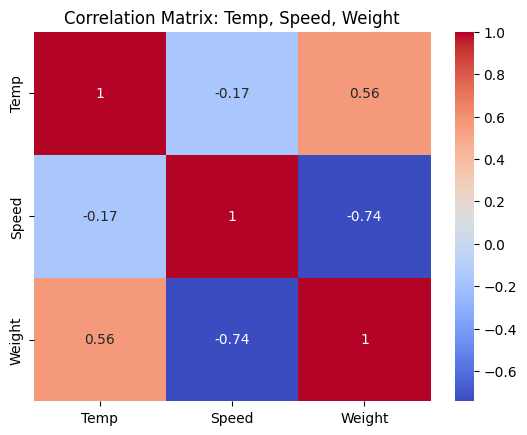

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix: Temp, Speed, Weight")
plt.show()


In [ ]:
data = {'Shift':['Morning','Evening'],
         'Scratch':[25,15],
         'Crack':[10,20],
         'Color':[5,8]}
df3 = pd.DataFrame(data).set_index('Shift')
df3


,Scratch,Crack,Color
Shift,,,
Morning,25,10,5
Evening,15,20,8


In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(df3)
print(f"Chi2 = {chi2:.2f}, p = {p:.4f}")


Chi2 = 6.43, p = 0.0402


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.002e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.50e-07
Time:                        14:20:44   Log-Likelihood:                -8.1084
No. Observations:                   5   AIC:                             20.22
Df Residuals:                       3   BIC:                             19.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5000      1.658     -0.905      0.4

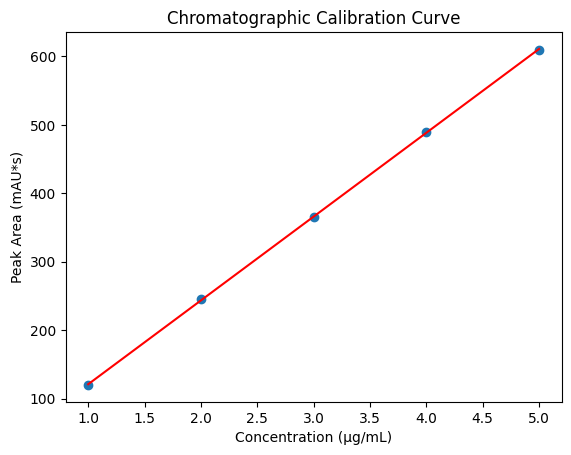

In [ ]:
import numpy as np

# Simulated calibration data
concentration = np.array([1, 2, 3, 4, 5])
peak_area = np.array([120, 245, 365, 490, 610])

# Regression model
X = sm.add_constant(concentration)
model_cal = sm.OLS(peak_area, X).fit()
print(model_cal.summary())

# Plot
plt.scatter(concentration, peak_area)
plt.plot(concentration, model_cal.predict(X), color='red')
plt.xlabel("Concentration (µg/mL)")
plt.ylabel("Peak Area (mAU*s)")
plt.title("Chromatographic Calibration Curve")
plt.show()
